In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import linear_model
from sklearn.model_selection import train_test_split

In [ ]:
import pandas as pd
import numpy as np

data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep=r"\s+", skiprows=22, header=None)

data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]

# Define feature names as provided in the dataset description or common usage
feature_names = np.array(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD',
                          'TAX', 'PTRATIO', 'B', 'LSTAT'])

# Recreate a 'boston' object as a dictionary to mimic the structure previously used
boston = {
    'data': data,
    'target': target,
    'feature_names': feature_names,
    'DESCR': 'Boston Housing Dataset (loaded from original source due to sklearn deprecation)',
    'filename': data_url
}

print(boston['data'].shape)

In [ ]:
# The boston object is loaded in the previous cell.
# Print the content of the boston dictionary.
print(boston)

In [ ]:
boston['feature_names']

In [ ]:
boston['target']

In [ ]:
print(boston['data'].shape) # .shape → returns (number_of_rows, number_of_columns)

In [ ]:
# The boston object is loaded in a previous cell.
# Print the keys of the boston dictionary.
print(boston.keys())

In [10]:
x = pd.DataFrame(boston['data'], columns = boston['feature_names'])
y = pd.DataFrame(boston['target']) #The model learns the relationship: 𝑦=𝑓(𝑋)

In [ ]:
x.head(10)

In [ ]:
y.head(10)

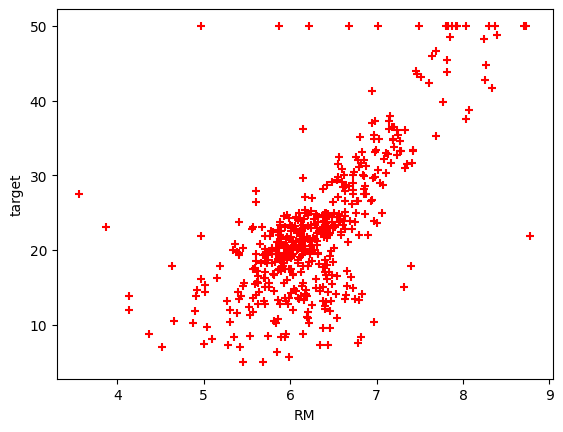

In [13]:
%matplotlib inline
import matplotlib.pyplot as plt

plt.xlabel('RM')  #plt.xlabel() → single label only
plt.ylabel('target')
#plt.scatter(x, y, ...) → all arguments inside the same parentheses
plt.scatter(boston['data'][:, 5], boston['target'], color='red', marker='+') #boston.data[:, 5] → RM feature (average number of rooms)
#boston.target → house price
plt.show()

In [14]:
reg = linear_model.LinearRegression()

In [15]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=42)

In [ ]:
reg.fit(x_train, y_train)#The model learns  how each housing feature affects the house price , optimal coefficients and intercept
 # Price=b0+b1x1+b2x2+⋯+b13x13

In [ ]:
print(reg.coef_) # Print coefiicients in house price prediction, coefficients represent how much the house price changes when a particular feature increases by 1 unit, keeping all other features constant.

In [ ]:
reg.fit(x_train, y_train)# Trains the Linear Regression model using the training data.
print(reg.score(x_test, y_test)) #Returns the R² score (coefficient of determination) of the model on test data.

In [ ]:
y_pred = reg.predict(x_test) #Uses the trained Linear Regression model to predict house prices.
#Predictions are made for the test dataset, which the model has not seen during training.

print(y_pred) #y_pred contains the predicted house prices.Each value corresponds to one house in x_test.
